In [1]:

import s3fs
s3 = s3fs.S3FileSystem(anon=False)


import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from geocube.api.core import make_geocube
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 

import owslib
from owslib.wfs import WebFeatureService
from owslib.ogcapi.features import Features
import geopandas as gpd
from datetime import datetime, timedelta

from math import cos, asin, sqrt
import re


import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain
from bs4 import BeautifulSoup # I mamba installed bs4
import requests

from datetime import date


sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
import fwiVis.fwiVis as fv


In [2]:
#w = Features(url = "https://pzh7fedpc0.execute-api.us-west-2.amazonaws.com") # Load base url of WFS
w = Features(url = "https://firenrt.delta-backend.com") 
feature_collections = w.feature_collections()
feature_collections


perm = w.collection('public.eis_fire_lf_perimeter_nrt')
print("Spatial extent: ", perm['extent']['spatial']['bbox']) # Coordinates of the spatial extent
print("Coordinate Reference System: ", perm['extent']['spatial']['crs']) 


## Get the most recent fire perimeters, and 7 days before most recent fire perimeter
most_recent_time = max(*perm["extent"]["temporal"]["interval"])
now = datetime.strptime(most_recent_time, "%Y-%m-%dT%H:%M:%S+00:00")
last_week = now - timedelta(weeks=1)
last_week = datetime.strftime(last_week, "%Y-%m-%dT%H:%M:%S+00:00")
last_month = now - timedelta(days=50)
last_month = datetime.strftime(last_month, "%Y-%m-%dT%H:%M:%S+00:00")
print("Most Recent Time =", most_recent_time)
print("Last week =", last_week)
print("Last month =", last_month)
two_months= now - timedelta(days=75)
two_months = datetime.strftime(two_months, "%Y-%m-%dT%H:%M:%S+00:00")
print("Two months =", two_months)

Spatial extent:  [[-162.5771942138672, 24.13558578491211, 165.92117309570312, 70.8248062133789]]
Coordinate Reference System:  http://www.opengis.net/def/crs/OGC/1.3/CRS84
Most Recent Time = 2024-08-20T12:00:00+00:00
Last week = 2024-08-13T12:00:00+00:00
Last month = 2024-07-01T12:00:00+00:00
Two months = 2024-06-06T12:00:00+00:00


In [3]:
NameOfFire = "PARK"

if NameOfFire:
    perurl = 'https://services3.arcgis.com/T4QMspbfLg3qTGWY/arcgis/rest/services/WFIGS_Interagency_Perimeters_Current/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson'
    polygdf = gpd.read_file(perurl)
    polygdf = polygdf.set_crs("EPSG:4326")
    polygdf['poly_IncidentName'] = polygdf['poly_IncidentName'].str.lower()
    #buffering WFIGS polygon layer by 187.5m, the "radius" of the spatial resolution of VIIRS
    polygdf = polygdf.to_crs(epsg=32633)
    polygdf['geometry'] = polygdf['geometry'].buffer(187.5)
    
    perm_results = w.collection_items(
    "public.eis_fire_snapshot_perimeter_nrt",  # name of the dataset we want
    bbox=('-125', '-65', '24', '50'),  # coordinates of bounding box
    datetime=[two_months + "/" + most_recent_time],  # date range
    limit=9999,  # max number of items returned
    )
    
    lf_perm_results = w.collection_items(
    "public.eis_fire_lf_perimeter_nrt",  # name of the dataset we want
    bbox=('-125', '-65', '24', '50'),  # coordinates of bounding box
    datetime=[two_months + "/" + most_recent_time],  # date range
    limit=9999,  # max number of items returned
    )

    mydf = gpd.GeoDataFrame.from_features(perm_results["features"])
    mydf = mydf.set_crs("EPSG:4326")
    mydf = mydf.to_crs(epsg=32633)
    
    mylfdf = gpd.GeoDataFrame.from_features(lf_perm_results["features"])
    mylfdf = mylfdf.set_crs("EPSG:4326")
    mylfdf = mylfdf.to_crs(epsg=32633)
    
    poly_join_inner_df = mydf.sjoin(polygdf, how="inner")
    lfpoly_join_inner_df = mylfdf.sjoin(polygdf, how="inner")
    
    NameOfFire = NameOfFire.lower()
    
    if NameOfFire in poly_join_inner_df['poly_IncidentName'].values:
        fireid = poly_join_inner_df[poly_join_inner_df['poly_IncidentName'] == NameOfFire]
        userPlace = fireid['fireid'].values[0]
        print("fireid associated with", NameOfFire,  "fire is", userPlace)
        
        activePerm_results = w.collection_items(
        "public.eis_fire_snapshot_fireline_nrt",  # name of the dataset we want
        filter= f'fireid = {userPlace}',
        limit=9999
        )

        perm_results = w.collection_items(
        "public.eis_fire_snapshot_perimeter_nrt",  # name of the dataset we want
        filter= f'fireid = {userPlace}',
        limit=9999,  # max number of items returned
        )

        df = gpd.GeoDataFrame.from_features(perm_results["features"])
        df = df.set_crs("EPSG:4326")

        activePermdf= gpd.GeoDataFrame.from_features(activePerm_results["features"])
        if(len(activePermdf) == 0):
            print("Fire not found")
        #activePermdf = activePermdf.set_geometry("geometry")
        activePermdf= activePermdf.set_crs("EPSG:4326")
        
        
    elif NameOfFire in lfpoly_join_inner_df['poly_IncidentName'].values:
        fireid = lfpoly_join_inner_df[lfpoly_join_inner_df['poly_IncidentName'] == NameOfFire]
        userPlace = fireid['fireid'].values[0]
        print("This fire is no longer in the snapshot layer; however, it is in the large fire layers. Scroll below to plot it's perimeters over time. The fireid associated with", NameOfFire,  "fire is", userPlace)
        
        
    else: 
        print("The name is not present in the WFIGS dataset of current fire incidents, so we could not join a name to the fireid. Use the map below to find the fireid directly.")
        

fireid associated with park fire is 36147
Fire not found


AttributeError: You are calling a geospatial method on the GeoDataFrame, but the active geometry column to use has not been set. 
There are no existing columns with geometry data type. You can add a geometry column as the active geometry column with df.set_geometry. 

In [4]:
perm_results = w.collection_items(
    "public.eis_fire_lf_perimeter_nrt",  # name of the dataset we want
    filter= f'fireid = {userPlace}',
    limit=9999,  # max number of items returned
    )

df = gpd.GeoDataFrame.from_features(perm_results["features"])
df = df.set_crs("EPSG:4326")


def get_st(lat, lon, stations, flag_bad = True):
    '''
    Read in data from a station at a lat long. Optionally, set data where interpolation may be too far from data as NaN. 
    
    INPUTS:
        
        lat (str):  A  lattitude
        lon (str):  A longitude
        stations (DataFrame): a dataframe as outputted by st_avail. A dataframe with columns for station lat, lon, and ID. 
        flag_bad (bool): Filter out data where the difference in the observation and the interpolation is over 20. This could indicate that the interpolation is way off. Default to True. 
    
    '''
        
    st = stations.loc[(stations.Lat == lat) & (stations.Lon == lon)]
    return(st)
    #dat = pd.read_csv("s3://veda-data-store-staging/EIS/other/station-FWI/20000101.20220907.hrlyInterp/FWI/727970-94240.spline.DailyFWIfromHourlyInterp.csv")
    if (st.File_path.str.contains("https").iloc[0]):
        dat = pd.read_csv((st.File_path.iloc[0]), index_col = False)
        #"s3://" + 
      
    else:
        print(f'{File_path.iloc[0]} is not an https, assuming s3.')
        dat = pd.read_csv(("s3://" + st.File_path.iloc[0]), index_col = False)

    dat = fv.date_convert(dat)
    if flag_bad:
        mask = dat['OBSMINUTEDIFF_TEMP'].loc[dat.OBSMINUTEDIFF_TEMP > 20]  ## Kluge. Basically, use this as a flag. 
        dat.iloc[mask.index, 4:-4 ] = np.nan
    
    return(dat)

In [44]:
#import datetime.datetime

def plot_st_history(st_id_map, st_dict, stations, title = None, path = None, lat_lon = None, USAF_WBAN = None, seasons = [5, 6, 7, 8, 9], year = None, plot_var = "FWI", clim_normal_min = datetime(1991, 1, 1), 
clim_normal_max = datetime(2020, 12, 31), highlight = None, highlight_lab = "Period of Fire"):

    '''
    Plots weather station data against historic means. Stations can be plotted form a file path, an USAF_WBAN id, or a lat and lon combination. If no station is at the exact lat lon, the function will search for the closest one. 
    
    INPUTS:
        st_dict (dict): A  dictionary with "Lat" and "Lon" entries for each weather station. A dictionary of the output from st_avail.
        stations (DataFrame): a dataframe as outputted by st_avail. A dataframe with columns for station lat, lon, and ID.
        st_id_map (DataFrame): a dataframe that connects Station IDs to full names and locations. 
        title (str):  An optional title for the plot. Optional. "None" is default. If "None", title will be the WMO ID of the station. 
        path (str):  Path to staion data csv. Optional. Default to "None". 
        lat_lon (list): A list of the form [lat_float, lon_float]. Optional. If lat and lon are not exact matches, function will search for closest station. 
        USAF_WBAN (list): List of the form [USAF, WBAN]. Optional. 
        seasons (list): List with single-digit representations of months to include in averaging across years. Default [5, 6, 7] or May, June and July. 
        year (str): The year of station data to compare to historic means. Defaults to "None", where the most recent data will be compared.
        plot_var (str): Variable to plot. Defaults to "FWI". 
        clim_normal_min (datetime): minimum period for climate normal. Defaults to January 1, 1991. If station data doesn not extend as far back as minimum, normal will be on min of station data and will throw a warning. 
        clim_normal_max (datetime): Maximum period for climate normal. Defaults to December 31st, 2020. If station data doesn not extend into maximum, normal will be on max of station data and will throw a warning. 
        highlight (list): Two element list specifying subset of x axis to highlight. Default to None. 
        highlight_lab (str): Optional label for highlight. 
        '''
    
    if(all([path == None, lat_lon == None, USAF_WBAN == None])):
        print("Error: No specifying information provided. Please include a path to station, a lat-lon, or a USAF_WBAN id. ")
    if(path == None):
        if( not USAF_WBAN == None ):
            
            st = stations.loc[(stations.USAF == USAF_WBAN[0]) & (stations.WBAN == USAF_WBAN[1])]
            if(~st.File_path.str.contains("https").iloc[0]):
                path = "s3://" + st.File_path.iloc[0]
            else:
                path = st.File_path.iloc[0]
        else:
            st = stations.loc[(stations.Lat == lat_lon[0]) & (stations.Lon== lat_lon[1])]
            if(len(st) == 0):
                st_cls = fv.closest(st_dict, pd.DataFrame(data = {"Lat" :[lat_lon[0]], "Lon" :  [lat_lon[1]]}))
                st = stations.loc[(stations.Lat == st_cls["Lat"]) & (stations.Lon == st_cls["Lon"])]
                
            path = st.File_path.iloc[0]
    
    if(title == None):
        split = re.split(pattern = "/", string = path)
        split = split[-1]
        WMO_id = re.sub(pattern = "\..*", repl = "",  string = split)
        extra = ""
        if("s3://" in path):  
            id_split = re.split(pattern = "-", string = WMO_id)
            labs = st_id_map[(st_id_map.USAF == str(id_split[0])) & (st_id_map.WBAN == str(id_split[1]))]
            extra = str(*labs['STATION NAME'])  + str(*labs['CTRY'])+ ", " + str(*labs['STATE'])
        title = "Weather Station" + extra +  "WMO ID (" + WMO_id + ")"

    print(path)
    st = pd.read_csv(path)
    if(not np.any(st.columns.isin(["HH"]))):
         st['HH'] = '12'
    st.YYYY = st.YYYY.astype("int")
    st.MM = st.MM.astype("int")
    st.DD = st.DD.astype("int")
    st.HH = st.HH.astype("int")
    st = fv.date_convert(st)
    
    max_season = max(seasons)
    if(max_season <= 9):
        max_season = "0" + str(max_season)
    min_season = min(seasons)
    if(min_season <= 9):
        min_season = "0" + str(min_season)
    min_season = str(min_season)
    max_season = str(max_season)
    
    if(year == None):
        print("Plotting most-recent year and seasons:" + str(seasons))
        #ctime = datetime.datetime.now()
        #year = str(ctime.year)
        year = str(max(st.time.dt.year))
    else:
        year = year
    
    max_day = year + "-" + max_season + "-28 23:00:00" ## Hack
    min_day = year + "-" + min_season + "-01 00:00:00"
        

    st['isinseason'] = st.MM.isin(seasons) # Is May, June or July? 
    mj = st[st['isinseason'] == True]
    mj = mj.set_index("time")
    

    # Try to use 1991-2020, or user supplied range as climate normal. If not possible, get as close as you can.     
    if((min(st.time) > clim_normal_min) |  (max(st.time) < clim_normal_max)):
        print("WARNING: Station record does not cover assumed climate normal (1991-2020).")
        print("Using range " + str(max(clim_normal_min, min(st.time))) + ":" + str(min(clim_normal_max, max(st.time))) + " instead.")
        mj = mj[mj.index > max(clim_normal_min, min(st.time))]
        mj = mj[mj.index < min(clim_normal_max, max(st.time))]
    mj = mj[mj.index.strftime('%m-%d') != '02-29'] # Drop leap-day becuase it's only sampled once every 4 years
    mean_quant = mj.groupby([mj.index.day.astype("int"), mj.index.month.astype("int")]).mean(numeric_only=True)


    dates = ( year + "-" + mean_quant.index.get_level_values(level=1).astype("str") + "-" + mean_quant.index.get_level_values(level=0).astype("str"))

    mean_quant["dates"] = pd.to_datetime(dates)
    mean_quant = mean_quant.sort_values(by = "dates")
    mean_quant.set_index("dates", inplace = True)


    upper = mj.select_dtypes(include='number').groupby([mj.index.day, mj.index.month]).quantile((1-0.025), numeric_only=True)
    upper["dates"] = pd.to_datetime(dates)
    upper = upper.sort_values(by = "dates")
    upper.set_index("dates", inplace = True)

    lower = mj.select_dtypes(include='number').groupby([mj.index.day, mj.index.month]).quantile((0.025),  numeric_only=True)
    lower["dates"] = pd.to_datetime(dates)
    lower = lower.sort_values(by = "dates")
    lower.set_index("dates", inplace = True)


    mid_lower = mj.select_dtypes(include='number').groupby([mj.index.day, mj.index.month]).quantile((0.25),  numeric_only=True)
    mid_lower["dates"] = pd.to_datetime(dates)
    mid_lower = mid_lower.sort_values(by = "dates")
    mid_lower.set_index("dates", inplace = True)


    mid_upper = mj.select_dtypes(include='number').groupby([mj.index.day, mj.index.month]).quantile((0.75),  numeric_only=True)
    mid_upper["dates"] = pd.to_datetime(dates)
    mid_upper = mid_upper.sort_values(by = "dates")
    mid_upper.set_index("dates", inplace = True)
    
    st = st.sort_values(by = ["time"])
    try:
        upper[plot_var].rolling(5).mean()
    except:
        print("print_var is not present in this weather station. Columns are: " + str(st.columns))
        return(None)
    
    daily_vars = ["DC", "BUI", "DMC", "PREC_MM"] # Vars that are daily even with hourly station data
    
    fig, ax = plt.subplots()
    ax.fill_between(upper.index, upper[plot_var].rolling(5).mean(), lower[plot_var].rolling(5).mean(), 
                    facecolor='grey', 
                    alpha=0.2,
                    label= "95th Percentile")
    ax.fill_between(mid_upper.index, mid_upper[plot_var].rolling(5).mean(), mid_lower[plot_var].rolling(5).mean(), 
                    facecolor='grey', 
                    alpha=0.4,
                    label= "25th Percentile")
    ax.plot(mean_quant.index, mean_quant[plot_var].rolling(5).mean(), 
            color = "black",
            label= "Historic Mean Per Day")
    if(plot_var in daily_vars):
        tmp = st.dropna()
        ax.plot(tmp[(tmp.time >= min_day) & (tmp.time <= max_day)].time.astype('datetime64[ns]'), tmp[(tmp.time >= min_day) & (tmp.time <= max_day)][plot_var], color = 'blue', label='Current')
    else:
        ax.plot(st[(st.time >= min_day) & (st.time <= max_day)].time.astype('datetime64[ns]'), st[(st.time >= min_day) & (st.time <= max_day)][plot_var], color='blue', label='Current')
    if(highlight is not None):
        y_min, y_max = plt.gca().get_ylim()
        highlight_polygon = np.array([[highlight[0], y_min], [highlight[0], y_max], [highlight[1], y_max], [highlight[1], y_min]])

        plt.fill(*highlight_polygon.T, color='yellow', alpha=0.3, label=highlight_lab)
   
    ax.set_ylabel(plot_var)
    ax.set_xlabel('Date')
    ax.set_title(title)
    ax.legend()
    default_fontsize = plt.rcParams['font.size']
    legend_fontsize = default_fontsize * 0.65
    plt.legend(fontsize=legend_fontsize)
    # box = ax.get_position()
    # #ax.set_position([box.x0, box.y0 + box.height * 0.1,box.width, box.height * 0.9])
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=5)
    fig.autofmt_xdate()
    return st

In [16]:
df[df.t == df.t.max()].centroid

/tmp/ipykernel_7197/3165441012.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df[df.t == df.t.max()].centroid


47    POINT (-121.78454 40.11010)
48    POINT (-121.78454 40.11010)
49    POINT (-121.78454 40.11010)
50    POINT (-121.78454 40.11010)
51    POINT (-121.78454 40.11010)
52    POINT (-121.78454 40.11010)
53    POINT (-121.78454 40.11010)
dtype: geometry

Searching for availible stations atveda-data-store-staging/EIS/other/station-FWI/19900101.NRT/FWI


/tmp/ipykernel_7197/2842590434.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  foi["Lat"] = df.geometry.centroid.x
/tmp/ipykernel_7197/2842590434.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  foi["Lon"] = df.geometry.centroid.y


The closest station is 5291.86330129437 km away.
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/857030-99999.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/857030-99999.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/857030-99999.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/857030-99999.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]


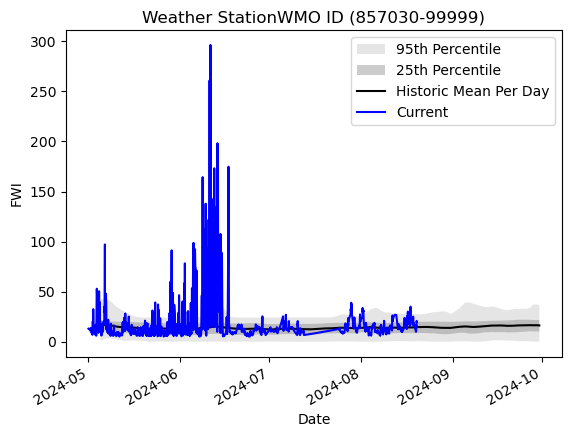

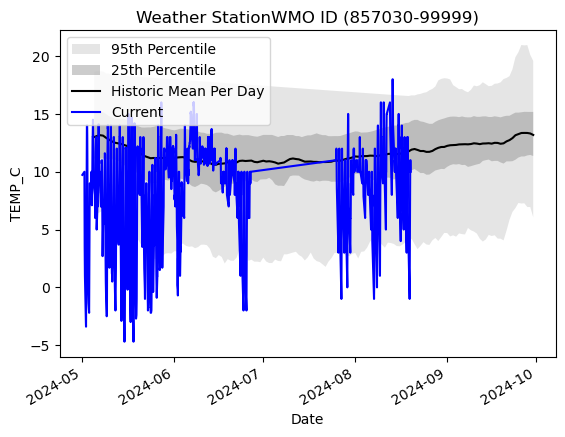

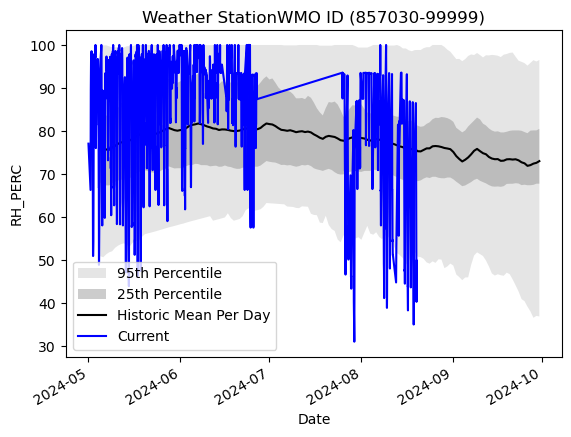

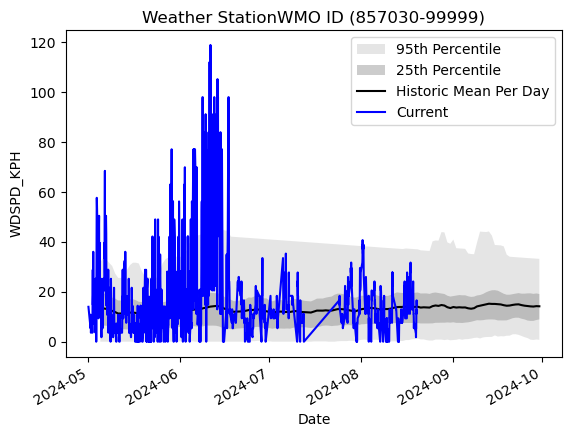

In [17]:
#import requests
#from bs4 import BeautifulSoup
#import BeautifulSoup
#def plot_FWI_over_time(userPlace):

files = fv.listFD("https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI", "csv") # This will update through time. Not nessisary now because focus on 2019
st_id_map = pd.read_csv('https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/isd-history.csv')

stations = fv.st_avail(files, st_id_map)
#print(stations)
st_dict = stations[['Lat', 'Lon']].to_dict('records')

## Load up that fire 
fireID = str(userPlace)
#gdf = fv.load_large_fire(fireID, year = "2024", path_region = "CONUS_NRT_DPS")
foi = df

foi["Lat"] = df.geometry.centroid.x
foi["Lon"] = df.geometry.centroid.y
foi = foi.rename(columns = {"lat": "Lat", "lon": "Lon"})
foi = foi.iloc[0] # First element

## Look for closest station
st_cls = fv.closest(st_dict, foi)
st_cls

## Get station Data
st = get_st(lat = st_cls["Lat"], lon = st_cls["Lon"], stations = stations, flag_bad=False)


coords = st_cls
# Create a list with latitude and longitude as numeric values
coords = [coords['Lat'], coords['Lon']]

vars = ['FWI', 'TEMP_C', 'RH_PERC', 'WDSPD_KPH']
for var in vars: 
    plot_st_history(st_id_map, st_dict, stations, lat_lon=coords,  plot_var = var)

This station is 69.90073224484016 km away from the centroid of the fire. 
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/745048-93210.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
Using range 2005-12-31 17:00:00:2020-12-31 00:00:00 instead.
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/745048-93210.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
Using range 2005-12-31 17:00:00:2020-12-31 00:00:00 instead.
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/745048-93210.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8, 9]
Using range 2005-12-31 17:00:00:2020-12-31 00:00:00 instead.
https://portal.nccs.nasa.gov/datashare/GlobalFWI/StnFWI/19900101.NRT/FWI/745048-93210.linear.HourlyFWIFromHourlyInterpContinuous.csv
Plotting most-recent year and seasons:[5, 6, 7, 8

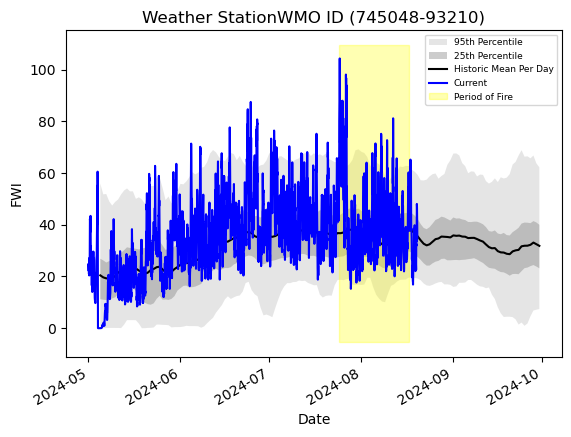

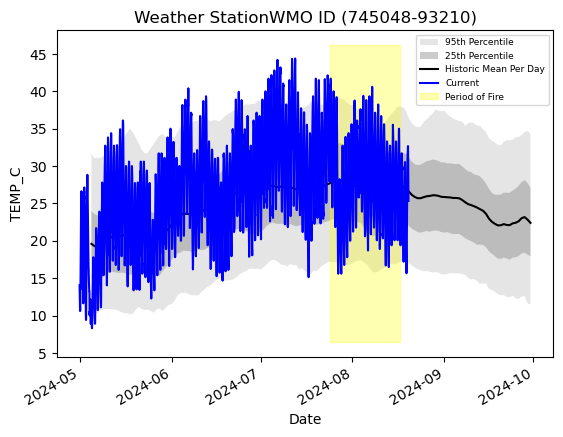

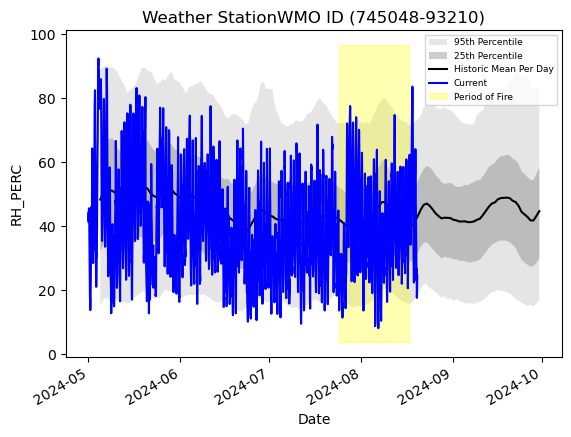

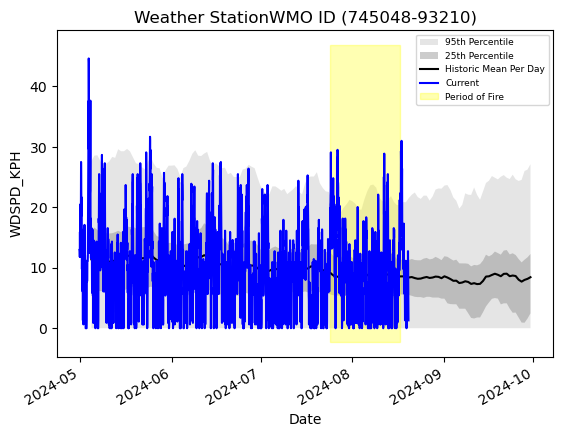

In [45]:
#### Some hacks for quick plotting

ex_st = ['745048', '93210']
fire_lon = df[df.t == df.t.max()].geometry.iloc[0].centroid.x
fire_lat = df[df.t == df.t.max()].geometry.iloc[0].centroid.y

st_lat = st_id_map.loc[(st_id_map.USAF == ex_st[0]) | (st_id_map.WBAN == ex_st[1])].LAT.iloc[0]
st_lon = st_id_map.loc[(st_id_map.USAF == ex_st[0]) | (st_id_map.WBAN == ex_st[1])].LON.iloc[0]

dist = fv.distance(st_lat, st_lon, fire_lat, fire_lon)
print(f"This station is {dist} km away from the centroid of the fire. ")
vars = ['FWI', 'TEMP_C', 'RH_PERC', 'WDSPD_KPH']
for var in vars:
    plot_st_history(st_id_map, st_dict, stations, lat_lon=coords, USAF_WBAN = ['745048', '93210'], plot_var = var, highlight=[df.t.astype("datetime64[ns]").min(),df.t.astype("datetime64[ns]").max()])    
    
    

In [40]:
st.File_path.str.contains("https").iloc[0]

True

In [24]:
st_id_map.loc[(st_id_map.USAF == usaf) | (st_id_map.WBAN == wban)]

In [33]:
df.t.astype("datetime64[ns]").min()

Timestamp('2024-07-24 12:00:00')

In [19]:
#dat = pd.read_csv((st.File_path.iloc[0]), index_col = False)

In [42]:
df = df.sort_values(by = "t", ascending = False)

df.explore(style_kwds = {'fillOpacity':0})

In [39]:
df[df.t == "2024-07-27T00:00:00"].t.values

array(['2024-07-27T00:00:00'], dtype=object)

(array([19929., 19933., 19936., 19940., 19944., 19948., 19952.]),
 [Text(19929.0, 0, '2024-07-25'),
  Text(19933.0, 0, '2024-07-29'),
  Text(19936.0, 0, '2024-08-01'),
  Text(19940.0, 0, '2024-08-05'),
  Text(19944.0, 0, '2024-08-09'),
  Text(19948.0, 0, '2024-08-13'),
  Text(19952.0, 0, '2024-08-17')])

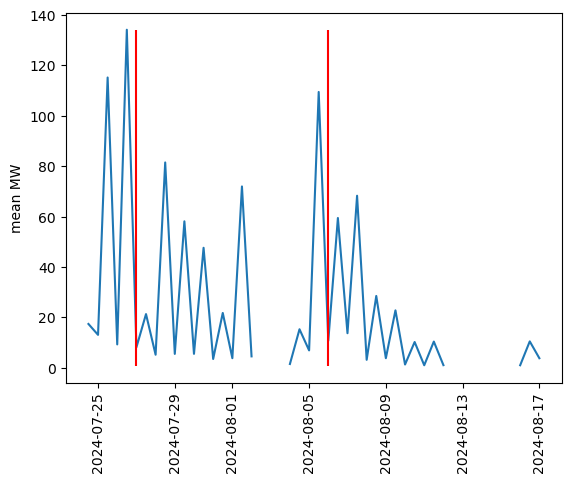

In [43]:
plt.plot(df.t.astype("datetime64[ns]"), df.meanfrp)
plt.vlines(df[df.t == "2024-07-27T00:00:00"].t.astype("datetime64[ns]"), ymin = df.meanfrp.min(), ymax = df.meanfrp.max(), color = "red")
#plt.vlines(df[df.t == "2024-08-05T00:00:00"].t.astype("datetime64[ns]"), ymin = df.meanfrp.min(), ymax = df.meanfrp.max(), color = "red") Debatably a major run
plt.vlines(df[df.t == "2024-08-06T00:00:00"].t.astype("datetime64[ns]"), ymin = df.meanfrp.min(), ymax = df.meanfrp.max(), color = "red")

plt.ylabel("mean MW")
plt.xticks(rotation=90)

In [14]:
s3.ls("s3://veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/")

['veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/.zarray',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/.zattrs',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.0.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.10.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.100.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1000.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1001.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1002.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1003.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1004.0.0',
 'veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/0.1005.0.0',
 'veda-

In [11]:
import xarray as xr
import zarr

In [21]:
test = xr.open_zarr("s3://veda-data-store-staging/EIS/zarr/20240809/FWI.GEOS-5.zarr/GEOS-5_FWI/") #engine = 'scipy'

ContainsArrayError: path '' contains an array